# 📘 Clustering Jerárquico (Agglomerative Clustering)

## 🎯 ¿Qué es el Clustering Jerárquico?

El **Clustering Jerárquico** es un método de aprendizaje no supervisado que
construye una **estructura en forma de árbol (jerarquía)** de los datos,
agrupando observaciones similares paso a paso.

A diferencia de K-Means:
- ❌ No necesita inicializar centroides.
- ❌ No requiere fijar obligatoriamente el número de clusters desde el inicio.
- ✅ Permite visualizar la estructura completa mediante un **dendrograma**.

---

# 🔎 Tipos de Clustering Jerárquico

Existen dos enfoques:

## 1️⃣ Aglomerativo (Bottom-Up)  ← el más usado
- Cada punto empieza como un cluster individual.
- En cada paso, se fusionan los dos clusters más cercanos.
- Se repite hasta que todos los puntos estén en un solo cluster.

## 2️⃣ Divisivo (Top-Down)
- Empieza con un solo cluster que contiene todos los puntos.
- Se divide recursivamente en subclusters.
- Es menos común en práctica.

En sklearn se implementa el enfoque **Aglomerativo**.

---

# 🧠 ¿Cómo funciona el método Aglomerativo?

### Paso 1:
Cada observación comienza como su propio cluster.

### Paso 2:
Se calcula la distancia entre todos los clusters.

### Paso 3:
Se fusionan los dos clusters más cercanos.

### Paso 4:
Se recalculan las distancias considerando el nuevo cluster.

### Paso 5:
Se repite el proceso hasta:
- Tener un único cluster, o
- Alcanzar el número deseado de clusters.

---

# 1️⃣ Importar librerías

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

# 2️⃣ Cargar dataset

In [3]:
iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
X = iris.drop(columns=["species"])

# 3️⃣ Escalar datos (MUY IMPORTANTE en clustering)

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4️⃣ Aplicar Agglomerative Clustering

In [6]:
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"   # ward minimiza varianza interna
)

In [7]:
labels = model.fit_predict(X_scaled)

In [8]:
iris["cluster"] = labels
iris

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,0
146,6.3,2.5,5.0,1.9,virginica,0
147,6.5,3.0,5.2,2.0,virginica,0
148,6.2,3.4,5.4,2.3,virginica,0


In [9]:
print("Clusters encontrados:", np.unique(labels))

Clusters encontrados: [0 1 2]


# 5️⃣ Evaluación con Silhouette Score

In [10]:
sil = silhouette_score(X_scaled, labels)
print("Silhouette Score:", round(sil, 3))

Silhouette Score: 0.447


# 6️⃣ Visualización

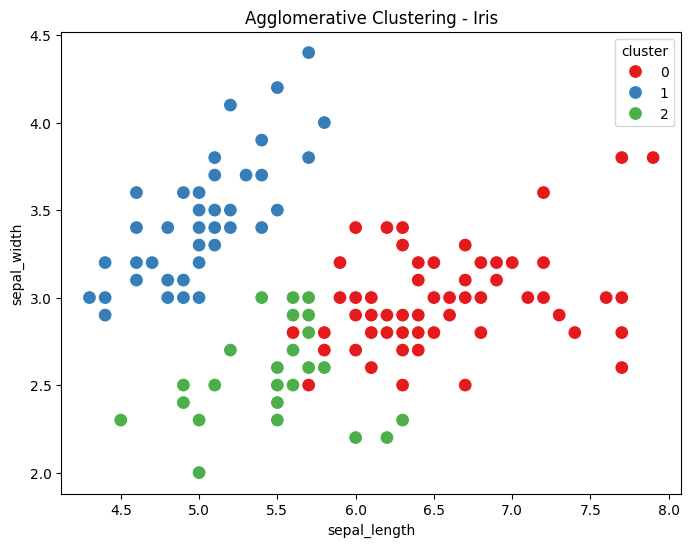

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=iris,
    x="sepal_length",
    y="sepal_width",
    hue="cluster",
    palette="Set1",
    s=100
)

plt.title("Agglomerative Clustering - Iris")
plt.show()